<a href="https://colab.research.google.com/github/joel0codes0ml/MACHINE-LEARNING-PROJECTS/blob/implementation-algorithms/Multi_Layer_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


loading and normalizng mage data

In [2]:
gray_scale = 255
x_train = x_train.astype('float32') / gray_scale
x_test = x_test.astype('float32') / gray_scale


In [3]:
print("Feature matrix (x_train):", x_train.shape)
print("Target matrix (y_train):", y_train.shape)
print("Feature matrix (x_test):", x_test.shape)
print("Target matrix (y_test):", y_test.shape)


Feature matrix (x_train): (60000, 28, 28)
Target matrix (y_train): (60000,)
Feature matrix (x_test): (10000, 28, 28)
Target matrix (y_test): (10000,)


visualizing the data

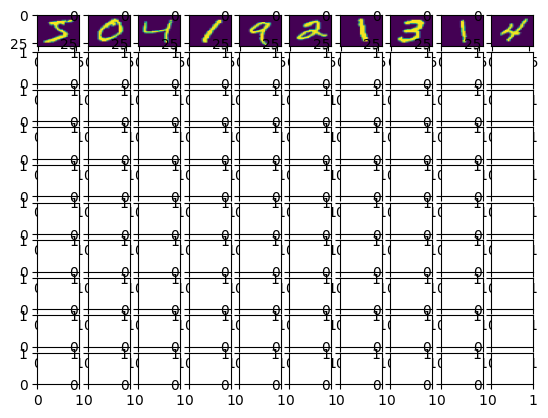

In [4]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
  for j in range(10):
    ax[i][j].imshow(x_train[k].reshape(28, 28), aspect='auto')
    k += 1
  plt.show()

building the neural network

In [5]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(10, activation='softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


compiling the model

In [7]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

training the model

In [8]:
mod = model.fit(x_train, y_train, epochs=10,
                batch_size = 2000,
                validation_split=0.2)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.2398 - loss: 2.2774 - val_accuracy: 0.5175 - val_loss: 1.8053
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6388 - loss: 1.6405 - val_accuracy: 0.7855 - val_loss: 1.1402
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7889 - loss: 1.0447 - val_accuracy: 0.8508 - val_loss: 0.7432
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8423 - loss: 0.7114 - val_accuracy: 0.8802 - val_loss: 0.5425
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8715 - loss: 0.5396 - val_accuracy: 0.8961 - val_loss: 0.4376
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8881 - loss: 0.4443 - val_accuracy: 0.9035 - val_loss: 0.3776
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8973 - loss: 0.3888 - val_accuracy: 0.9091 - val_loss: 0.3383
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9058 - loss: 0.3527 - val_accuracy: 0.9141 - v

evaluating the model

In [11]:
results = model.evaluate(x_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

Test loss, Test accuracy: [0.2783500850200653, 0.9217000007629395]


Visualizing training and validation perfomance

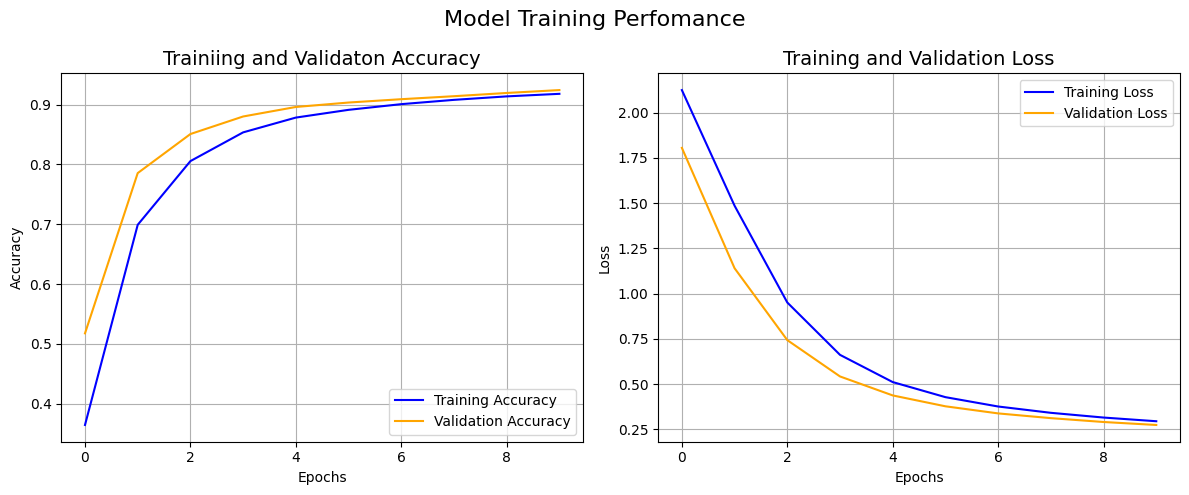

In [13]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Trainiing and Validaton Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Perfomance", fontsize=16)
plt.tight_layout()
plt.show()